# Real Nanonis datalog workflow tutorial

This notebook is a complete manual guide to `nanonis.workflows.datalog` and the shared cancellation/progress toolkit. It follows the structure of `scan_workflow_live_demo.ipynb`, but this workflow is strictly **read only**.

The live cells send only `Util.VersionGet`, `Signals.NamesGet`, `Signals.ValGet`, `Signals.ValsGet`, `ZCtrl.ZPosGet`, and other `*.Get` snapshot commands. They never send a `*.Set`, start a scan, move the tip, or change feedback.

Recommended order:

1. Run the local/API sections.
2. Confirm the host, port, and signal slots against the controller GUI.
3. Connect and run the short trace.
4. Inspect timestamps, data, diagnostics, metadata, and state equality.
5. Opt into cancellation and the 60-second acceptance cells only after the short trace passes.


## 1. Imports and public API map (no hardware I/O)

The main public types are:

- `TimeTraceConfig`: frozen, validated acquisition request.
- `TimeTraceWorkflow`: performs deadline-scheduled `Signals.ValsGet` polling.
- `TimeTraceResult`: immutable float64 arrays, accessors, and provenance.
- `inspect_non_finite_trace`: counts NaN/Inf values by signal.
- `CancelToken`, `ProgressEvent`, `cancel_on_sigint`: shared cooperative cancellation/progress tools.
- `TimeTraceResponseError`: malformed `Signals` response.
- `NonFiniteTimeTraceDataError`: `NaNPolicy.RAISE`, retaining the completed result.


In [1]:
from __future__ import annotations

import json
import logging
import sys
import threading
import time
from collections.abc import Mapping
from datetime import datetime, timezone
from numbers import Integral
from pathlib import Path
from typing import Any

import numpy as np

ROOT = Path.cwd().resolve()
if not (ROOT / "src" / "nanonis").exists():
    ROOT = ROOT.parent
if not (ROOT / "src" / "nanonis").exists():
    raise RuntimeError("Start Jupyter from the repository root or examples directory")
sys.path.insert(0, str(ROOT / "src"))

from nanonis.command import NanonisController
from nanonis.types import NaNPolicy
from nanonis.workflows import (
    CancelToken,
    NonFiniteTimeTraceDataError,
    ProgressEvent,
    TimeTraceConfig,
    TimeTraceResponseError,
    TimeTraceResult,
    TimeTraceWorkflow,
    WorkflowCancelledError,
    cancel_on_sigint,
    inspect_non_finite_trace,
)
from nanonis.workflows.datalog import MAX_TRACE_ELEMENTS

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")
print("Repository root:", ROOT)
print("Maximum stored signal elements:", f"{MAX_TRACE_ELEMENTS:,}")


Repository root: E:\Nanonis_Py\qcodes_nanonis
Maximum stored signal elements: 10,000,000


## 2. Configuration semantics and validation (no hardware I/O)

`duration_s` is the nominal span, not a wall-clock timeout. Samples are scheduled at `k * sample_interval_s`, including `t=0`. Therefore 1 second at a 1-second interval produces two samples. The count is float-safe: `0.3 / 0.1` produces four samples.

Signal indexes must be unique integers from 0 through 127. The total `n_samples * n_signals` must not exceed `MAX_TRACE_ELEMENTS`. Final values are float64; peak acquisition memory is approximately twice the final values buffer because the immutable result makes a defensive copy.


In [2]:
examples = [
    TimeTraceConfig((0,), duration_s=1.0, sample_interval_s=1.0),
    TimeTraceConfig((0,), duration_s=0.3, sample_interval_s=0.1),
    TimeTraceConfig((0,), duration_s=0.35, sample_interval_s=0.1),
    TimeTraceConfig((0, 1), duration_s=60.0, sample_interval_s=0.1),
]
for config in examples:
    elements = config.n_samples * len(config.signal_indexes)
    print(
        f"duration={config.duration_s:g}s interval={config.sample_interval_s:g}s "
        f"signals={len(config.signal_indexes)} -> samples={config.n_samples}, "
        f"elements={elements:,}, final values~{elements * 8 / 1e6:.3f} MB"
    )

invalid_examples = [
    dict(signal_indexes=(), duration_s=1.0),
    dict(signal_indexes=(0, 0), duration_s=1.0),
    dict(signal_indexes=(128,), duration_s=1.0),
    dict(signal_indexes=(0,), duration_s=0.01, sample_interval_s=0.1),
]
for kwargs in invalid_examples:
    try:
        TimeTraceConfig(**kwargs)
    except (TypeError, ValueError) as exc:
        print(type(exc).__name__, "->", exc)


duration=1s interval=1s signals=1 -> samples=2, elements=2, final values~0.000 MB
duration=0.3s interval=0.1s signals=1 -> samples=4, elements=4, final values~0.000 MB
duration=0.35s interval=0.1s signals=1 -> samples=4, elements=4, final values~0.000 MB
duration=60s interval=0.1s signals=2 -> samples=601, elements=1,202, final values~0.010 MB
ValueError -> signal_indexes must not be empty
ValueError -> signal indexes must be unique
ValueError -> signal indexes must be in [0, 127]
ValueError -> duration_s must be >= sample_interval_s


## 3. Cancellation toolkit in isolation (no hardware I/O)

`CancelToken.cancel()` is thread-safe. `cancelled` checks the flag, `wait(timeout)` is an interruptible sleep and returns `True` if cancellation occurred, and `raise_if_cancelled()` raises `WorkflowCancelledError`. Datalog treats cancellation specially and returns a partial result; transactional workflows use the exception to trigger restoration.


In [3]:
token_demo = CancelToken()
print("Initially cancelled:", token_demo.cancelled)
print("Immediate wait result:", token_demo.wait(0.0))
token_demo.cancel()
print("After cancel():", token_demo.cancelled)
try:
    token_demo.raise_if_cancelled()
except WorkflowCancelledError as exc:
    print("raise_if_cancelled():", exc)

event_demo = ProgressEvent(
    workflow="datalog.time_trace", fraction=0.5, message="halfway", elapsed_s=2.0
)
print(event_demo)


Initially cancelled: False
Immediate wait result: False
After cancel(): True
raise_if_cancelled(): workflow cancelled
ProgressEvent(workflow='datalog.time_trace', fraction=0.5, message='halfway', elapsed_s=2.0)


## 4. Configure and open the real TCP connection

Set the host and port for a free Nanonis TCP slot. The confirmation token prevents an accidental connection when using Run All. Connecting and every subsequent workflow operation in this notebook are read-only.


In [4]:
HOST = "127.0.0.1"
PORT = 6504
CONFIG_DIR = ROOT / "configs" / "commands"
CONNECT_CONFIRMATION = "CONNECT_READ_ONLY"  # Change to "CONNECT_READ_ONLY".

if CONNECT_CONFIRMATION != "CONNECT_READ_ONLY":
    raise RuntimeError("Set CONNECT_CONFIRMATION='CONNECT_READ_ONLY' after checking HOST/PORT")

nanonis = NanonisController(HOST, PORT, CONFIG_DIR, timeout=10.0)
nanonis.connect()
print("Connected:", nanonis.is_connected, f"({HOST}:{PORT})")


Connected: True (127.0.0.1:6504)


## 5. Discover and validate the Signals slot table (read only)

Never assume a signal index from another rig or session. `Signals.NamesGet` returns the controller's current 0–127 slot table. The workflow performs the same strict count and bounds checks when `resolve_names=True`.


In [5]:
def parse_signal_names(response: Any) -> tuple[str, ...]:
    if not isinstance(response, Mapping):
        raise TimeTraceResponseError("Signals.NamesGet must return a mapping")
    if "signals_names_number" not in response or "signals_names" not in response:
        raise TimeTraceResponseError("Signals.NamesGet is missing required fields")
    declared = response["signals_names_number"]
    if not isinstance(declared, Integral) or isinstance(declared, bool):
        raise TimeTraceResponseError("signals_names_number must be an integer")
    names = tuple(str(name) for name in response["signals_names"])
    if int(declared) != len(names):
        raise TimeTraceResponseError("declared name count does not match the array")
    return names

signal_names = parse_signal_names(nanonis.send("Signals.NamesGet"))
for index, name in enumerate(signal_names):
    print(f"{index:3d}: {name}")


  0: Current (A)
  1: Input 2 (V)
  2: Input 3 (V)
  3: Input 4 (V)
  4: Input 5 (V)
  5: Input 6 (V)
  6: Input 7 (V)
  7: Input 8 (V)
  8: Input 9 (V)
  9: Input 10 (V)
 10: Input 11 (V)
 11: Input 12 (V)
 12: Input 13 (V)
 13: Input 14 (V)
 14: Input 15 (V)
 15: Input 16 (V)
 16: Input 17 (V)
 17: Input 18 (V)
 18: Input 19 (V)
 19: Input 20 (V)
 20: Input 21 (V)
 21: Input 22 (V)
 22: Input 23 (V)
 23: Input 24 (V)
 24: Bias (V)
 25: Output 2 (V)
 26: Output 3 (V)
 27: Output 4 (V)
 28: X (m)
 29: Y (m)
 30: Z (m)
 31: Output 8 (V)
 32: Output 9 (V)
 33: Output 10 (V)
 34: Output 11 (V)
 35: Output 12 (V)
 36: Output 13 (V)
 37: Output 14 (V)
 38: Output 15 (V)
 39: Output 16 (V)
 40: Output 17 (V)
 41: Output 18 (V)
 42: Output 19 (V)
 43: Output 20 (V)
 44: Output 21 (V)
 45: Output 22 (V)
 46: Output 23 (V)
 47: Output 24 (V)
 48: Fast Output 3 (V)
 49: Output 26 (V)
 50: Output 27 (V)
 51: Output 28 (V)
 52: Output 29 (V)
 53: Output 30 (V)
 54: Output 31 (V)
 55: Output 32 (V)

In [6]:
def find_slots(text: str) -> list[tuple[int, str]]:
    needle = text.casefold()
    return [(index, name) for index, name in enumerate(signal_names) if needle in name.casefold()]

print("Z candidates:", find_slots("z"))
print("Current candidates:", find_slots("current"))

# Replace these only after comparing the table with the Nanonis GUI.
Z_SIGNAL_INDEX = 30
CURRENT_SIGNAL_INDEX = 0

if Z_SIGNAL_INDEX is None or CURRENT_SIGNAL_INDEX is None:
    raise RuntimeError("Set Z_SIGNAL_INDEX and CURRENT_SIGNAL_INDEX from the table above")
SIGNAL_INDEXES = (int(Z_SIGNAL_INDEX), int(CURRENT_SIGNAL_INDEX))
print("Selected:", [(index, signal_names[index]) for index in SIGNAL_INDEXES])


Z candidates: [(30, 'Z (m)'), (76, 'OC M1 Freq. Shift (Hz)'), (94, 'Counter 1 (Hz)'), (95, 'Counter 2 (Hz)'), (98, 'Z Control signal (A)'), (99, 'Z Error signal (A)'), (100, 'Z SafeTip signal (A)')]
Current candidates: [(0, 'Current (A)')]
Selected: [(30, 'Z (m)'), (0, 'Current (A)')]


## 6. Snapshot read-only controller state

The datalog workflow does not need this snapshot and does not restore anything because it mutates nothing. We take it solely as evidence: bias, setpoint, feedback, and RT/acquisition settings should be identical after every trace.


In [7]:
def read_only_snapshot(client: NanonisController) -> dict[str, Any]:
    return {
        "bias": client.send("Bias.Get"),
        "setpoint": client.send("ZCtrl.SetpntGet"),
        "feedback": client.send("ZCtrl.OnOffGet"),
        "rt_frequency": client.send("Util.RTFreqGet"),
        "acquisition_period": client.send("Util.AcqPeriodGet"),
        "rt_oversampling": client.send("Util.RTOversamplGet"),
    }

state_before = read_only_snapshot(nanonis)
state_before


{'bias': 0.0,
 'setpoint': 0.0,
 'feedback': 0,
 'rt_frequency': 20000.0,
 'acquisition_period': 0.019999999552965164,
 'rt_oversampling': 10}

## 7. Characterize direct `ValsGet` reads and both wait modes

The workflow sends one `Signals.ValsGet` for all slots on each tick. The size argument is the number of array elements, the index tuple follows, and the wire wait flag is 0 or 1. `wait_for_newest_data=True` may wait for a full new RT publication and is the default. This cell validates every response and measures call latency without changing state.


In [8]:
def vals_get(client: NanonisController, indexes: tuple[int, ...], *, wait: bool) -> np.ndarray:
    response = client.send("Signals.ValsGet", len(indexes), indexes, int(wait))
    if not isinstance(response, Mapping):
        raise TimeTraceResponseError("Signals.ValsGet must return a mapping")
    if "signals_values_size" not in response or "signals_values" not in response:
        raise TimeTraceResponseError("Signals.ValsGet is missing required fields")
    declared = response["signals_values_size"]
    if not isinstance(declared, Integral) or isinstance(declared, bool):
        raise TimeTraceResponseError("signals_values_size must be an integer")
    values = np.asarray(response["signals_values"], dtype=np.float64)
    if values.ndim != 1 or int(declared) != values.size or values.size != len(indexes):
        raise TimeTraceResponseError("Signals.ValsGet counts/shapes are inconsistent")
    return values
SIGNAL_INDEXES = (30,0,1)

for wait in (False, True):
    latencies = []
    rows = []
    for _ in range(20):
        started = time.perf_counter()
        rows.append(vals_get(nanonis, SIGNAL_INDEXES, wait=wait))
        latencies.append(time.perf_counter() - started)
    latency = np.asarray(latencies)
    print(
        f"wait={wait}: median={np.median(latency)*1e3:.2f} ms, "
        f"p95={np.percentile(latency, 95)*1e3:.2f} ms, last={rows[-1]}"
    )
z_from_vals = float(vals_get(nanonis, (int(Z_SIGNAL_INDEX),), wait=True)[0])
z_from_val = float(nanonis.send("Signals.ValGet", int(Z_SIGNAL_INDEX), 1))
z_from_zctrl = float(nanonis.send("ZCtrl.ZPosGet"))
print("Z cross-check (sequential reads):", {
    "Signals.ValsGet": z_from_vals,
    "Signals.ValGet": z_from_val,
    "ZCtrl.ZPosGet": z_from_zctrl,
})
print("Sequential spread (m):", np.ptp([z_from_vals, z_from_val, z_from_zctrl]))


wait=False: median=22.17 ms, p95=29.29 ms, last=[7.50000027e-07 0.00000000e+00 1.75018537e+00]
wait=True: median=43.80 ms, p95=52.54 ms, last=[7.50000027e-07 0.00000000e+00 1.75017822e+00]
Z cross-check (sequential reads): {'Signals.ValsGet': 7.500000265281415e-07, 'Signals.ValGet': 7.500000265281415e-07, 'ZCtrl.ZPosGet': 7.500000265281415e-07}
Sequential spread (m): 0.0


## 8. Run a short live time trace

`TimeTraceWorkflow(client, nan_policy=...)` stores the client and non-finite policy. `run(config, cancel=None, on_progress=None)` resolves names once, reads the Nanonis version once, then polls all selected slots. Progress callbacks run approximately once per second and at successful completion; callback exceptions are logged and do not abort acquisition.

Lateness is measured when acquisition starts, after sleeping. The tolerance is half the interval. Sample zero is excluded. Deadlines remain on the nominal grid under tolerated jitter and rebase only after a counted overrun, so there are no skipped ticks or catch-up bursts.


Requested samples: 51
 21.6%    1.047s  acquired 11/51 samples
 43.1%    2.141s  acquired 22/51 samples
 62.7%    3.157s  acquired 32/51 samples
 84.3%    4.219s  acquired 43/51 samples
100.0%    5.016s  complete
Completed samples: 51


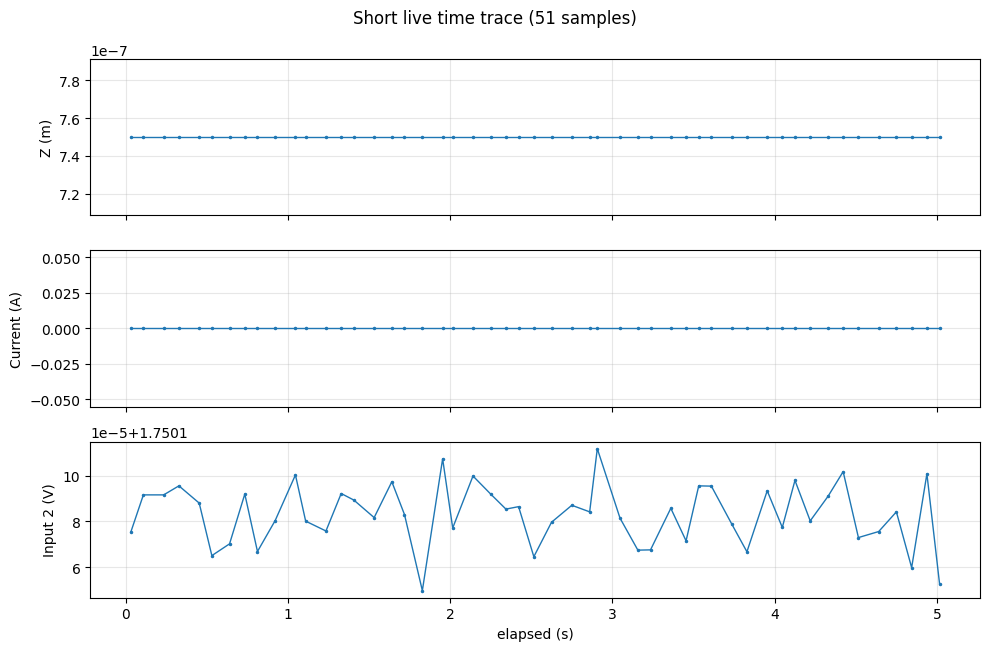

In [9]:
SHORT_DURATION_S = 5.0
SAMPLE_INTERVAL_S = 0.1
short_config = TimeTraceConfig(
    signal_indexes=SIGNAL_INDEXES,
    duration_s=SHORT_DURATION_S,
    sample_interval_s=SAMPLE_INTERVAL_S,
    wait_for_newest_data=True,
    resolve_names=True,
)
print("Requested samples:", short_config.n_samples)

progress_events: list[ProgressEvent] = []
def show_progress(event: ProgressEvent) -> None:
    progress_events.append(event)
    fraction = "open" if event.fraction is None else f"{100*event.fraction:5.1f}%"
    print(f"{fraction}  {event.elapsed_s:7.3f}s  {event.message}")

workflow = TimeTraceWorkflow(nanonis, nan_policy=NaNPolicy.WARN)
short_result = workflow.run(short_config, on_progress=show_progress)
print("Completed samples:", short_result.n_samples)

# Visualize the acquired trace: one subplot per signal versus recorded elapsed time.
import matplotlib.pyplot as plt

n_signals = len(short_result.signal_indexes)
fig, axes = plt.subplots(n_signals, 1, figsize=(10, 2.2 * n_signals), sharex=True, squeeze=False)
for axis, index, name in zip(axes[:, 0], short_result.signal_indexes, short_result.signal_names):
    axis.plot(short_result.elapsed_s, short_result.signal_by_index(index), lw=1, marker=".", ms=3)
    axis.set_ylabel(name)
    axis.grid(alpha=0.3)
axes[-1, 0].set_xlabel("elapsed (s)")
fig.suptitle(f"Short live time trace ({short_result.n_samples} samples)")
fig.tight_layout()
plt.show()

## 9. Inspect `TimeTraceResult` and every accessor

`elapsed_s` contains actual monotonic offsets recorded after each call, not nominal ticks. `values` has shape `(n_signals, n_samples)`. Both arrays are float64 defensive copies with writes disabled.

- `signal_by_index(index)` raises `KeyError` when the slot was not recorded.
- `signal_by_name(name)` raises `ValueError` when names were not resolved, are absent, or are ambiguous. Duplicate names are intentionally not guessed; use the index accessor.
- `to_metadata()` returns JSON-compatible acquisition/config/controller/software provenance and excludes the bulk arrays.


In [10]:
print("indexes:", short_result.signal_indexes)
print("names:", short_result.signal_names)
print("elapsed shape/dtype/writeable:", short_result.elapsed_s.shape, short_result.elapsed_s.dtype, short_result.elapsed_s.flags.writeable)
print("values shape/dtype/writeable:", short_result.values.shape, short_result.values.dtype, short_result.values.flags.writeable)
print("cancelled:", short_result.cancelled)
print("late samples:", short_result.late_sample_count)
print("Nanonis version:", short_result.nanonis_version)
short_diagnostics = inspect_non_finite_trace(short_result)
print("non-finite diagnostics:", short_diagnostics)
print("has non-finite data:", short_diagnostics.has_non_finite)

for index in short_result.signal_indexes:
    data = short_result.signal_by_index(index)
    print(index, signal_names[index], "first/last:", data[0], data[-1])

for name in short_result.signal_names:
    try:
        print(name, "->", short_result.signal_by_name(name).shape)
    except ValueError as exc:
        print(name, "->", exc)

metadata = short_result.to_metadata()
print(json.dumps(metadata, indent=2))


indexes: (30, 0, 1)
names: ('Z (m)', 'Current (A)', 'Input 2 (V)')
elapsed shape/dtype/writeable: (51,) float64 False
values shape/dtype/writeable: (3, 51) float64 False
cancelled: False
late samples: 0
Nanonis version: Generic 5
non-finite diagnostics: TimeTraceNonFiniteDiagnostics(nan_count=0, inf_count=0, affected_signal_indexes=(), affected_signal_names=())
has non-finite data: False
30 Z (m) first/last: 7.500000265281415e-07 7.500000265281415e-07
0 Current (A) first/last: 0.0 0.0
1 Input 2 (V) first/last: 1.7501752376556396 1.750152826309204
Z (m) -> (51,)
Current (A) -> (51,)
Input 2 (V) -> (51,)
{
  "format": "nanonis-time-trace",
  "software": {
    "name": "qcodes-nanonis",
    "version": "0.1.0",
    "git_commit": "3383307e5df177eb7d3641e4ecd22368c001a367"
  },
  "controller": {
    "nanonis_version": "Generic 5"
  },
  "signal_indexes": [
    30,
    0,
    1
  ],
  "signal_names": [
    "Z (m)",
    "Current (A)",
    "Input 2 (V)"
  ],
  "n_samples": 51,
  "requested_inter

## 10. Timing diagnostics and plots

Useful manual checks are the actual span, interval error distribution, and late-sample fraction. The live acceptance target for a 10 Hz trace is p95 absolute interval error at most 20 ms and at most 1% late samples. A short trace is only a smoke test; use the guarded 60-second section for acceptance evidence.


In [11]:
intervals = np.diff(short_result.elapsed_s)
interval_error = intervals - short_result.requested_interval_s
print("actual span (s):", short_result.elapsed_s[-1] if short_result.n_samples else None)
print("interval median (s):", np.median(intervals))
print("interval p95 absolute error (s):", np.percentile(np.abs(interval_error), 95))
print("interval min/max (s):", np.min(intervals), np.max(intervals))
print("late count:", short_result.late_sample_count)


actual span (s): 5.01600000000326
interval median (s): 0.09400000001187436
interval p95 absolute error (s): 0.03754999999946449
interval min/max (s): 0.0470000000204891 0.139999999984866
late count: 0


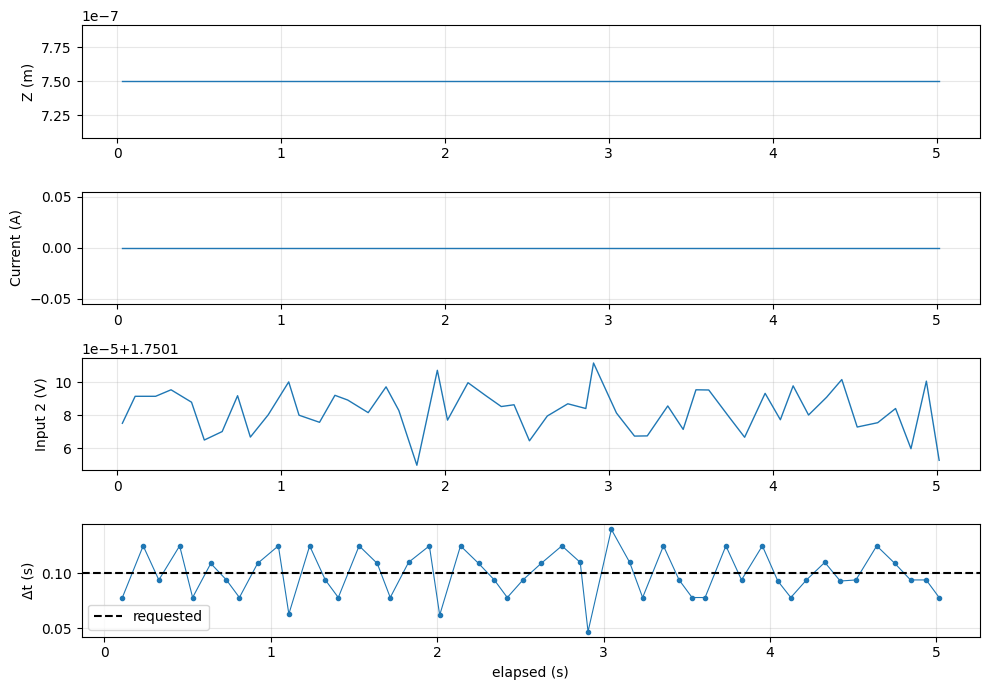

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(short_result.signal_indexes) + 1, 1, figsize=(10, 7), sharex=False)
for axis, index, name in zip(axes, short_result.signal_indexes, short_result.signal_names):
    axis.plot(short_result.elapsed_s, short_result.signal_by_index(index), lw=1)
    axis.set_ylabel(name)
    axis.grid(alpha=0.3)
axes[-1].plot(short_result.elapsed_s[1:], intervals, marker=".", lw=0.8)
axes[-1].axhline(short_result.requested_interval_s, color="k", ls="--", label="requested")
axes[-1].set_ylabel("Δt (s)")
axes[-1].set_xlabel("elapsed (s)")
axes[-1].legend()
axes[-1].grid(alpha=0.3)
fig.tight_layout()


## 11. Non-finite inspection and `NaNPolicy` (offline demonstration)

`inspect_non_finite_trace(result)` returns NaN/Inf counts plus affected indexes and resolved names. Workflow policy behavior is:

- `ALLOW`: return silently.
- `WARN`: log diagnostics and return.
- `RAISE`: raise `NonFiniteTimeTraceDataError`; `.result` and `.diagnostics` retain the completed data.

The following client is local and scripted; it performs no TCP I/O.


In [13]:
class ScriptedTraceClient:
    def __init__(self, rows: list[list[float]]) -> None:
        self.rows = iter(rows)
        self.sent: list[tuple[str, tuple[Any, ...]]] = []

    def send(self, command: str, *args: Any, timeout: float | None = None) -> Any:
        self.sent.append((command, args))
        if command == "Util.VersionGet":
            return {"version": "offline-demo"}
        if command == "Signals.ValsGet":
            row = next(self.rows)
            return {"signals_values_size": len(row), "signals_values": row}
        raise AssertionError(f"Unexpected command: {command}")

offline_config = TimeTraceConfig((0,), duration_s=0.01, sample_interval_s=0.01, resolve_names=False)
for policy in NaNPolicy:
    client = ScriptedTraceClient([[float("nan")], [float("inf")]])
    try:
        result = TimeTraceWorkflow(client, nan_policy=policy).run(offline_config)
        print(policy.value, "returned:", inspect_non_finite_trace(result))
    except NonFiniteTimeTraceDataError as exc:
        print(policy.value, "raised with retained result:", exc.diagnostics, exc.result.values)


WARNING nanonis.workflows.datalog.workflow: Time-trace data contains 1 NaN and 1 infinite values; affected signal indexes: (0,)


allow returned: TimeTraceNonFiniteDiagnostics(nan_count=1, inf_count=1, affected_signal_indexes=(0,), affected_signal_names=())
warn returned: TimeTraceNonFiniteDiagnostics(nan_count=1, inf_count=1, affected_signal_indexes=(0,), affected_signal_names=())
raise raised with retained result: TimeTraceNonFiniteDiagnostics(nan_count=1, inf_count=1, affected_signal_indexes=(0,), affected_signal_names=()) [[nan inf]]


## 12. Malformed-response behavior (offline demonstration)

Every `ValsGet` tick must return a mapping with `signals_values_size` and a one-dimensional `signals_values` array. The declared size, actual array length, and requested signal count must agree. Malformed data raises `TimeTraceResponseError`; it is never truncated into a partial result. Transport errors likewise propagate. Only deliberate token cancellation returns partial data.


In [14]:
class MalformedClient:
    def send(self, command: str, *args: Any, timeout: float | None = None) -> Any:
        if command == "Util.VersionGet":
            return {"version": "offline-demo"}
        if command == "Signals.ValsGet":
            return {"signals_values_size": 2, "signals_values": [1.0]}
        raise AssertionError(command)

try:
    TimeTraceWorkflow(MalformedClient()).run(offline_config)
except TimeTraceResponseError as exc:
    print(type(exc).__name__, "->", exc)


TimeTraceResponseError -> Signals.ValsGet declared value count does not match array length


## 13. Cooperative cancellation with a timer (optional live test)

This is the most reliable cancellation test in a notebook: a background timer calls `token.cancel()` while the main thread is waiting. The workflow returns the acquired prefix with `cancelled=True`; it does not raise. Enable the guard to run it.


In [15]:
RUN_TIMER_CANCELLATION = False
timer_cancel_result = None
if RUN_TIMER_CANCELLATION:
    timer_token = CancelToken()
    timer = threading.Timer(2.0, timer_token.cancel)
    timer.start()
    try:
        timer_cancel_result = workflow.run(
            TimeTraceConfig(SIGNAL_INDEXES, duration_s=10.0, sample_interval_s=0.1),
            cancel=timer_token,
            on_progress=show_progress,
        )
    finally:
        timer.cancel()
    print("cancelled:", timer_cancel_result.cancelled)
    print("samples acquired/requested:", timer_cancel_result.n_samples, "/", 101)
else:
    print("Skipped. Set RUN_TIMER_CANCELLATION=True to run.")


Skipped. Set RUN_TIMER_CANCELLATION=True to run.


## 14. First-Ctrl-C cancellation with `cancel_on_sigint` (optional live test)

Inside `cancel_on_sigint(token)`, the first SIGINT requests graceful cancellation and the second restores normal interrupt behavior and raises `KeyboardInterrupt`. Notebook frontends differ in how the Interrupt button delivers SIGINT, so run the timer test first. If the frontend intercepts SIGINT before Python's handler, use the timer path instead.


In [16]:
RUN_SIGINT_CANCELLATION = False
sigint_result = None
if RUN_SIGINT_CANCELLATION:
    sigint_token = CancelToken()
    print("Start the trace, then press Interrupt once. Pressing twice raises immediately.")
    with cancel_on_sigint(sigint_token):
        sigint_result = workflow.run(
            TimeTraceConfig(SIGNAL_INDEXES, duration_s=30.0, sample_interval_s=0.1),
            cancel=sigint_token,
            on_progress=show_progress,
        )
    print("cancelled:", sigint_result.cancelled, "samples:", sigint_result.n_samples)
else:
    print("Skipped. Set RUN_SIGINT_CANCELLATION=True to run.")


Skipped. Set RUN_SIGINT_CANCELLATION=True to run.


## 15. Verify the workflow changed no controller state

Exact equality is the acceptance criterion for these read-only snapshots. If it fails, first check whether another operator or automation changed the rig concurrently; the datalog command sequence itself contains no setters.


In [17]:
state_after_short = read_only_snapshot(nanonis)
print("State unchanged:", state_after_short == state_before)
for key in state_before:
    print(f"{key:20s}: before={state_before[key]!r} after={state_after_short[key]!r}")


State unchanged: True
bias                : before=0.0 after=0.0
setpoint            : before=0.0 after=0.0
feedback            : before=0 after=0
rt_frequency        : before=20000.0 after=20000.0
acquisition_period  : before=0.019999999552965164 after=0.019999999552965164
rt_oversampling     : before=10 after=10


## 16. Optional 60-second live acceptance

This reproduces the M5a-4 timing gate: 601 samples of Z and current at 10 Hz, no more than 6 late samples, final elapsed time in `[60.0, 60.6]` seconds, and p95 absolute interval error no more than 20 ms. Direct Z cross-checks happen before and after the timed loop so their extra round trips cannot corrupt trace timing.


In [18]:
def z_cross_checks(client: NanonisController, repetitions: int = 10) -> list[dict[str, float]]:
    records = []
    for _ in range(repetitions):
        vals_z = float(vals_get(client, (int(Z_SIGNAL_INDEX),), wait=True)[0])
        zctrl_z = float(client.send("ZCtrl.ZPosGet"))
        records.append({"Signals.ValsGet": vals_z, "ZCtrl.ZPosGet": zctrl_z})
    return records

RUN_60_SECOND_ACCEPTANCE = False
acceptance_result = None
acceptance_report = None
if RUN_60_SECOND_ACCEPTANCE:
    acceptance_before = read_only_snapshot(nanonis)
    z_before = z_cross_checks(nanonis)
    acceptance_config = TimeTraceConfig(
        SIGNAL_INDEXES, duration_s=60.0, sample_interval_s=0.1,
        wait_for_newest_data=True, resolve_names=True,
    )
    acceptance_result = workflow.run(acceptance_config, on_progress=show_progress)
    z_after = z_cross_checks(nanonis)
    acceptance_after = read_only_snapshot(nanonis)
    dt = np.diff(acceptance_result.elapsed_s)
    p95_error = float(np.percentile(np.abs(dt - 0.1), 95))
    final_elapsed = float(acceptance_result.elapsed_s[-1])
    acceptance_report = {
        "sample_count_ok": acceptance_result.n_samples == 601,
        "late_count_ok": acceptance_result.late_sample_count <= 6,
        "span_ok": 60.0 <= final_elapsed <= 60.6,
        "p95_interval_error_s": p95_error,
        "interval_error_ok": p95_error <= 0.02,
        "state_unchanged": acceptance_before == acceptance_after,
        "z_cross_checks_before": z_before,
        "z_cross_checks_after": z_after,
    }
    acceptance_report["all_timing_gates_passed"] = all([
        acceptance_report["sample_count_ok"],
        acceptance_report["late_count_ok"],
        acceptance_report["span_ok"],
        acceptance_report["interval_error_ok"],
    ])
    print(json.dumps(acceptance_report, indent=2))
else:
    print("Skipped. Set RUN_60_SECOND_ACCEPTANCE=True to run.")


Skipped. Set RUN_60_SECOND_ACCEPTANCE=True to run.


## 17. Save a result without pandas or pickle (optional local write)

The workflow deliberately does not persist data. A compact portable pair is compressed NPZ for arrays plus JSON from `to_metadata()`. This cell is disabled by default and writes only to `manual_runs/`; it never asks Nanonis to save a file.


In [19]:
SAVE_SHORT_RESULT = False
if SAVE_SHORT_RESULT:
    output_dir = ROOT / "manual_runs"
    output_dir.mkdir(exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    base = output_dir / f"datalog_{stamp}"
    np.savez_compressed(
        base.with_suffix(".npz"),
        elapsed_s=short_result.elapsed_s,
        values=short_result.values,
    )
    base.with_suffix(".json").write_text(
        json.dumps(short_result.to_metadata(), indent=2), encoding="utf-8"
    )
    print("Saved:", base.with_suffix(".npz"), base.with_suffix(".json"))
else:
    print("Skipped. Set SAVE_SHORT_RESULT=True to save locally.")


Skipped. Set SAVE_SHORT_RESULT=True to save locally.


## 18. Disconnect

Always close the TCP slot when manual testing is finished. This does not alter instrument settings.


In [20]:
if 'nanonis' in globals():
    if nanonis.is_connected:
        nanonis.disconnect()
    print("Disconnected:", not nanonis.is_connected)
else:
    print("No controller object was created.")


Disconnected: True


## Manual acceptance checklist and troubleshooting

Record these items in a dated live report:

- The complete slot table and the chosen Z/current indexes.
- `wait=False` versus `wait=True` latency distributions.
- Short-trace shapes, late count, interval p95, and unchanged state snapshot.
- Timer cancellation returning a truncated result with `cancelled=True`.
- First-Ctrl-C behavior if the notebook frontend delivers SIGINT to Python.
- The 60-second timing report and before/after Z cross-checks.

Common failures:

- `TimeTraceResponseError` during name resolution: command schema/controller response mismatch or an index outside the returned table.
- `TimeTraceResponseError` during sampling: declared size, actual array, or requested signal count disagrees; do not use the partial data.
- Timeout/connection/protocol error: the workflow aborts and propagates it. Reconnect before sending more commands because a timed-out stream may be desynchronized.
- High late count: measure direct `ValsGet` latency, reduce requested polling rate, and check host/controller load.
- Duplicate signal names: use `signal_by_index`; name lookup intentionally rejects ambiguity.
- Non-finite values: inspect diagnostics and choose `ALLOW`, `WARN`, or `RAISE` explicitly for the experiment.
